In [1]:
import common_functions

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd
import numpy as np
import xarray as xr

In [2]:
dust_df = pd.read_csv("DATA/processed/3_dust_points_vars_2026-05-07.csv")
control_ds = xr.open_dataset("DATA/processed/4_control_grid_2026-05-06.nc")
control_ds_dust_sites = xr.open_dataset("DATA/processed/5_control_grid_dust_sites_2026-05-07.nc")

Create a side-by-side bar chart comparing:
- frequency of soil textures at dust points
- frequency of soil textures in the full soil raster

## Surface categories

In [3]:
soil_cmap, texture_colors, texture_dict = common_functions.get_texture_map_features()
land_cover_dict, land_cover_colors, classes = common_functions.get_land_cover_features()
soil_order_dict, category_colors = common_functions.get_soil_order_features()

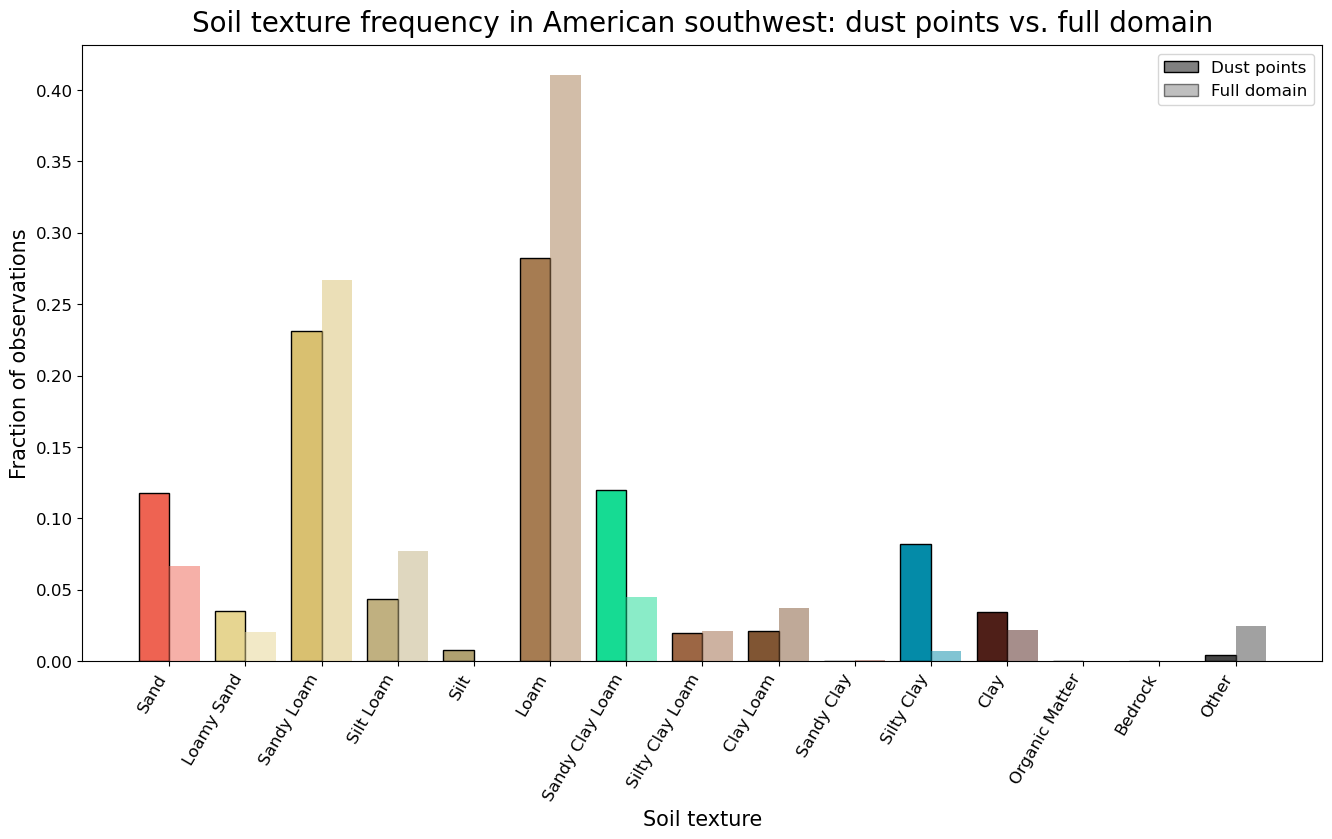

In [4]:
#--- Calculate bins
dust_counts = {k: np.sum(dust_df['texture'] == k) for k in texture_dict.keys()}
dust_total = sum(dust_counts.values())
dust_fraction = {k: v / dust_total for k, v in dust_counts.items()}

non_dust_counts = {k: np.sum(control_ds['soil_texture'] == k) for k in texture_dict.keys()}
non_dust_total = sum(non_dust_counts.values())
non_dust_fraction = {k: v / non_dust_total for k, v in non_dust_counts.items()}

categories = list(texture_dict.keys())
labels = [texture_dict[k] for k in categories]
x = np.arange(len(categories))
width = 0.4

fig, ax = plt.subplots(figsize=(16, 8))

for i, k in enumerate(categories):
    color = texture_colors[i]
    ax.bar(x[i] - width / 2, dust_fraction[k], width, color=color, edgecolor="black", label="Dust points" if i == 0 else "")
    ax.bar(x[i] + width / 2, non_dust_fraction[k], width, color=color, alpha=0.5, label="Full domain" if i == 0 else "")

ax.tick_params(labelsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=60, ha="right")
ax.set_ylabel("Fraction of observations", fontsize=15)
ax.set_xlabel("Soil texture", fontsize=15)
ax.set_title(f"Soil texture frequency in American southwest: dust points vs. full domain", fontsize=20, pad=10)

legend_elements = [
    Patch(facecolor="gray", edgecolor="black", label="Dust points"),
    Patch(facecolor="gray", edgecolor="black", alpha=0.5, label="Full domain")
]
ax.legend(handles=legend_elements, fontsize=12)

plt.savefig(f"plots/3_texture_1_bar_chart.png",
            dpi=300, bbox_inches='tight')
plt.show()

In [5]:
def add_medians_to_plot(ax_bar, median_dust, median_control):

    ax_bar.axvline(
        median_dust,
        color="tab:orange",
        linestyle="--",
        linewidth=2,
        zorder=0
    )
    ax_bar.text(x=median_dust, 
                y=0.84,
                s=f'Median: {median_dust:.2f}', 
                color="tab:orange",
                alpha=0.8, 
                fontsize=10,
                fontweight='bold',
                rotation=90,
                verticalalignment='center',
                horizontalalignment='right',
                transform=ax_bar.get_xaxis_transform())

    ax_bar.axvline(
        median_control,
        color="tab:blue",
        linestyle="--",
        linewidth=2,
        zorder=0
    )
    
    ax_bar.text(x=median_control, 
                y=0.84,
                s=f'Median: {median_control:.2f}', 
                color="tab:blue",
                alpha=0.8, 
                fontsize=10,
                fontweight='bold',
                rotation=90,
                verticalalignment='center',
                horizontalalignment='right',
                transform=ax_bar.get_xaxis_transform())
    
    return

## Continuous (wind and moisture)

Plotting wind speed bar chart...


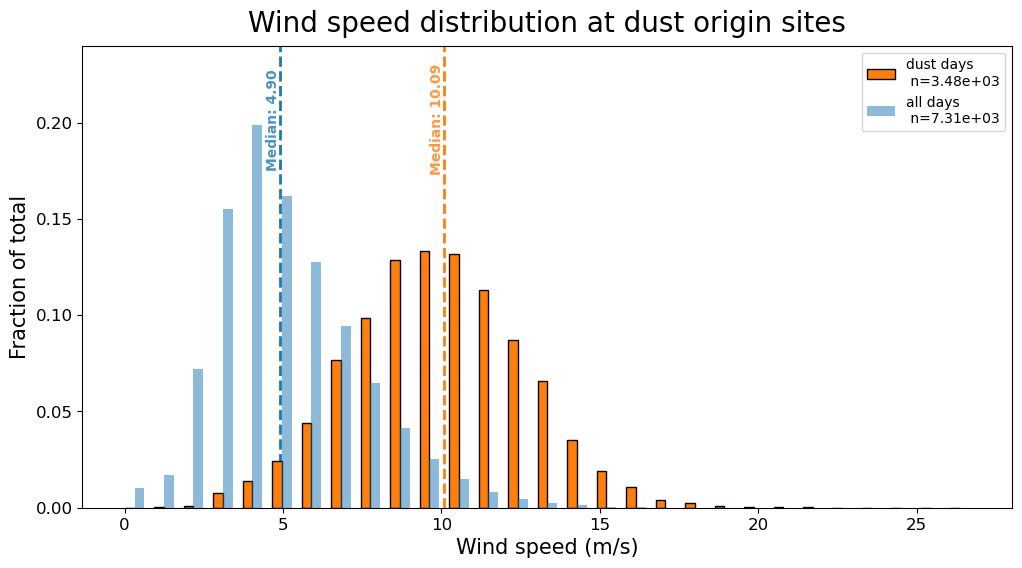

In [6]:
print("Plotting wind speed bar chart...")

#--- Calculate bins
bins = np.linspace(0, 27, 30)
counts_dust_days, _ = np.histogram(dust_df["wind_speed"], bins=bins)
counts_all_days, _ = np.histogram(control_ds_dust_sites["wind_speed"], bins=bins)
width = (bins[1] - bins[0]) / 3
density_dust_days = counts_dust_days / np.sum(counts_dust_days)
density_all_days = counts_all_days / np.sum(counts_all_days)

fig, ax_bar = plt.subplots(figsize=(12, 6))

plt.bar(bins[:-1], density_dust_days, 
        width=width, 
        align='edge', 
        color="tab:orange",
        edgecolor="black",
        linewidth=1,
        label=f"dust days \n n={len(dust_df["wind_speed"]) :.2e}",)
plt.bar(bins[:-1] + width, density_all_days, 
        width=width, 
        align='edge', 
        color="tab:blue",
        label=f"all days \n n={len(control_ds_dust_sites["wind_speed"]) :.2e}",
        alpha=0.5)

median_dust = dust_df["wind_speed"].median(skipna=True)
median_control = control_ds_dust_sites["wind_speed"].median(skipna=True)
add_medians_to_plot(ax_bar, median_dust, median_control)

ax_bar.tick_params(labelsize=12)
ax_bar.set_ylim(0,0.24)
ax_bar.set_ylabel("Fraction of total", fontsize=15)
ax_bar.set_xlabel("Wind speed (m/s)", fontsize=15)
ax_bar.set_title("Wind speed distribution at dust origin sites", fontsize=20, pad=10)

ax_bar.legend()
plt.savefig(f"plots/1_wind_speed_bar_chart.png",
            dpi=300, bbox_inches='tight')
plt.show()

Plotting moisture bar chart...


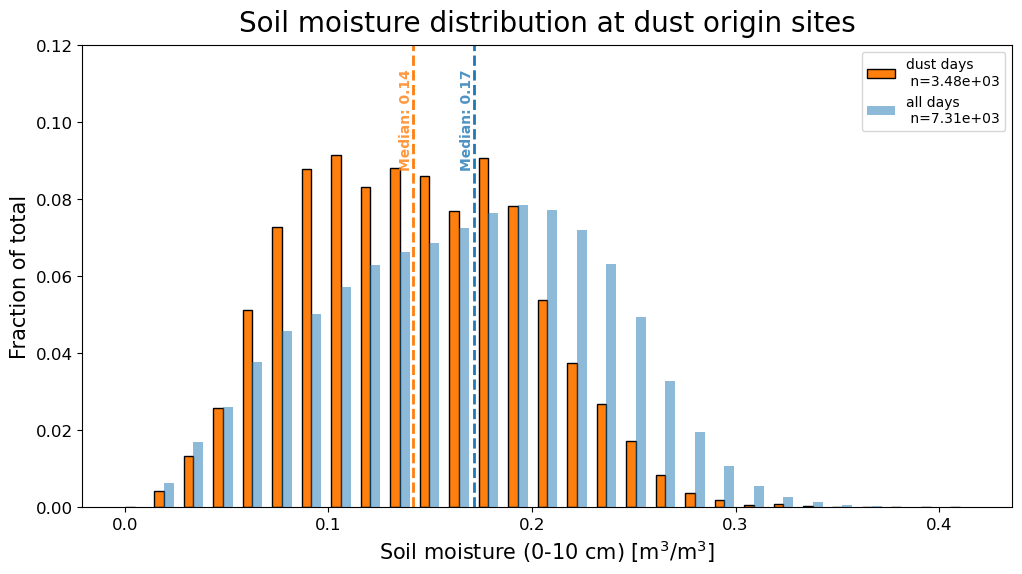

In [7]:
print("Plotting moisture bar chart...")

#--- Calculate bins
bins = np.linspace(0, 0.42, 30)
counts_dust_days, _ = np.histogram(dust_df["moisture"], bins=bins)
counts_all_days, _ = np.histogram(control_ds_dust_sites["SoilMoi00_10cm_tavg"], bins=bins)
width = (bins[1] - bins[0]) / 3
density_dust_days = counts_dust_days / np.sum(counts_dust_days)
density_all_days = counts_all_days / np.sum(counts_all_days)

fig, ax_bar = plt.subplots(figsize=(12, 6))

plt.bar(bins[:-1], density_dust_days, 
        width=width, 
        align='edge', 
        color="tab:orange",
        edgecolor="black",
        linewidth=1,
        label=f"dust days \n n={len(dust_df["moisture"]) :.2e}",)
plt.bar(bins[:-1] + width, density_all_days, 
        width=width, 
        align='edge', 
        color="tab:blue",
        label=f"all days \n n={len(control_ds["SoilMoi00_10cm_tavg"]) :.2e}",
        alpha=0.5)

median_dust = dust_df["moisture"].median(skipna=True)
median_control = control_ds_dust_sites["SoilMoi00_10cm_tavg"].median(skipna=True)
add_medians_to_plot(ax_bar, median_dust, median_control)

ax_bar.tick_params(labelsize=12)
ax_bar.set_ylim(0,0.12)
ax_bar.set_ylabel("Fraction of total", fontsize=15)
ax_bar.set_xlabel("Soil moisture (0-10 cm) [m$^3$/m$^3$]", fontsize=15)
ax_bar.set_title("Soil moisture distribution at dust origin sites", fontsize=20, pad=10)

ax_bar.legend()
plt.savefig(f"plots/2_soil_moisture_0_bar_chart.png",
            dpi=300, bbox_inches='tight')
plt.show()

## Combined surface categories

In [8]:
def map_ids_to_names(df, col_list):
    '''
    Replacing the IDs in texture, soil_order, and usage with the full names. 
    '''
    #--- Map texture IDs to names
    if texture_dict is not None and 'texture' in col_list:
        df['texture'] = (
            df['texture']
            .round()
            .astype('Int64')
            .map(texture_dict)
        )
    #--- Map usage IDs to names
    if land_cover_dict is not None and 'usage' in col_list:
        df['usage'] = (
            df['usage']
            .round()
            .astype('Int64')
            .map(land_cover_dict)
        )
    #--- Map soil order IDs to names
    if soil_order_dict is not None and 'soil_order' in col_list:
        df['soil_order'] = (
            df['soil_order']
            .round()
            .astype('Int64')
            .map(soil_order_dict)
        )
    return df

In [37]:
def combined_freq(col_list, dust_df, control_df):
    '''
    col_list = ['usage', 'texture', 'soil_order']
    Getting the compared count and frequency of these combinations of categories 
    for the dust and control data
    '''
    temp_dust_df = dust_df.copy()
    temp_control_df = control_df.copy()

    temp_dust_df = map_ids_to_names(temp_dust_df, col_list)
    temp_control_df = map_ids_to_names(temp_control_df, col_list)

    grouped_dust_df = (
        temp_dust_df.groupby(col_list)
        .size()
        .reset_index(name='dust_count')
        )
    
    grouped_control_df = (
        temp_control_df.groupby(col_list)
        .size()
        .reset_index(name='control_count')
        )
    
    merged = grouped_dust_df.merge(
        grouped_control_df,
        on=col_list,
        how='outer'   # keeps all combinations from both
    )

    #--- Fill in missing valies with NaNs
    merged[['dust_count', 'control_count']] = (
        merged[['dust_count', 'control_count']]
        .fillna(0)
        .astype(int)
    )
    
    total_count_dust = len(temp_dust_df)
    total_count_control = len(temp_control_df)
    merged['dust_freq'] = round(merged['dust_count'] / total_count_dust, 3)
    merged['control_freq'] = round(merged['control_count'] / total_count_control, 3)
    return merged

In [48]:
col_list = ['usage', 'texture', 'soil_order']
control_df = (
    control_ds[['usage', 'soil_texture', 'soil_order']]
    .to_dataframe()
    .reset_index()
)
control_df = control_df.rename(columns={
    'soil_texture': 'texture'
})
combo_three = combined_freq(col_list, dust_df, control_df)
print(combo_three.sort_values('control_freq', ascending=False)[:6])

                               usage     texture soil_order  dust_count  \
238         Temp/Sub-polar Shrubland  Sandy Loam  Aridisols          97   
216         Temp/Sub-polar Shrubland        Loam  Mollisols          13   
213         Temp/Sub-polar Shrubland        Loam  Aridisols          38   
319  Tropical/Sub-tropical Shrubland  Sandy Loam  Aridisols         100   
301  Tropical/Sub-tropical Shrubland        Loam  Aridisols         162   
302  Tropical/Sub-tropical Shrubland        Loam   Entisols         128   

     control_count  dust_freq  control_freq  
238            331      0.028         0.047  
216            290      0.004         0.041  
213            278      0.011         0.040  
319            228      0.029         0.033  
301            222      0.047         0.032  
302            227      0.037         0.032  


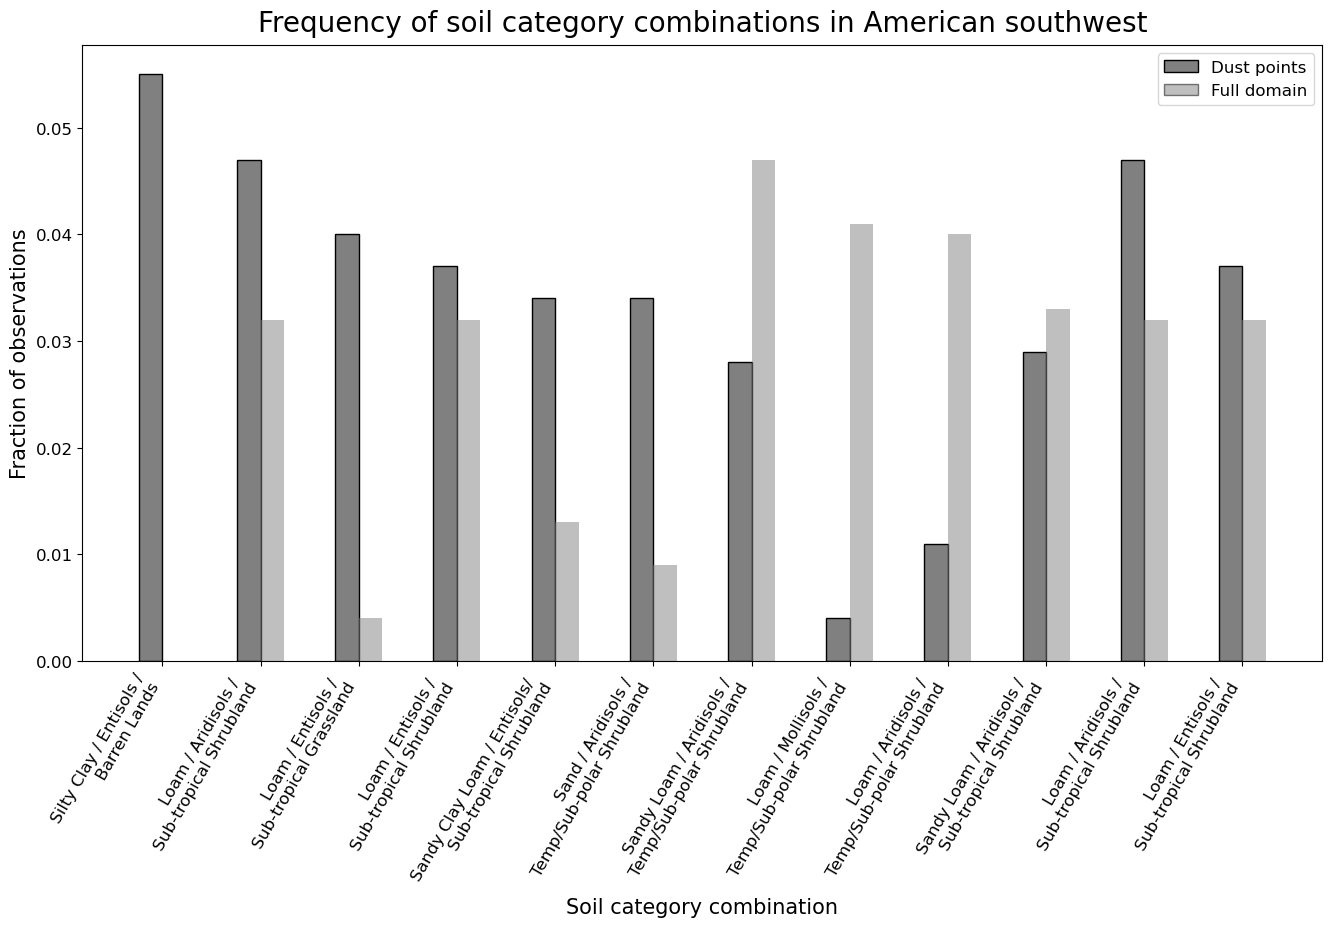

In [58]:
fig, ax = plt.subplots(figsize=(16, 8))

n_categories=12
x = np.arange(n_categories)
width = 0.24

ax.bar(x[0] - width/2, combo_three['dust_freq'][27], width=width, color="grey", edgecolor="black", label="Dust points")
ax.bar(x[0] + width/2, combo_three['control_freq'][27], width=width, color="grey", alpha=0.5, label="Full domain")
ax.bar(x[1] - width/2, combo_three['dust_freq'][301], width=width, color="grey", edgecolor="black", label="Dust points")
ax.bar(x[1] + width/2, combo_three['control_freq'][301], width=width, color="grey", alpha=0.5, label="Full domain")
ax.bar(x[2] - width/2, combo_three['dust_freq'][277], width=width, color="grey", edgecolor="black", label="Dust points")
ax.bar(x[2] + width/2, combo_three['control_freq'][277], width=width, color="grey", alpha=0.5, label="Full domain")
ax.bar(x[3] - width/2, combo_three['dust_freq'][302], width=width, color="grey", edgecolor="black", label="Dust points")
ax.bar(x[3] + width/2, combo_three['control_freq'][302], width=width, color="grey", alpha=0.5, label="Full domain")
ax.bar(x[4] - width/2, combo_three['dust_freq'][315], width=width, color="grey", edgecolor="black", label="Dust points")
ax.bar(x[4] + width/2, combo_three['control_freq'][315], width=width, color="grey", alpha=0.5, label="Full domain")
ax.bar(x[5] - width/2, combo_three['dust_freq'][231], width=width, color="grey", edgecolor="black", label="Dust points")
ax.bar(x[5] + width/2, combo_three['control_freq'][231], width=width, color="grey", alpha=0.5, label="Full domain")
ax.bar(x[6] - width/2, combo_three['dust_freq'][238], width=width, color="grey", edgecolor="black", label="Dust points")
ax.bar(x[6] + width/2, combo_three['control_freq'][238], width=width, color="grey", alpha=0.5, label="Full domain")
ax.bar(x[7] - width/2, combo_three['dust_freq'][216], width=width, color="grey", edgecolor="black", label="Dust points")
ax.bar(x[7] + width/2, combo_three['control_freq'][216], width=width, color="grey", alpha=0.5, label="Full domain")
ax.bar(x[8] - width/2, combo_three['dust_freq'][213], width=width, color="grey", edgecolor="black", label="Dust points")
ax.bar(x[8] + width/2, combo_three['control_freq'][213], width=width, color="grey", alpha=0.5, label="Full domain")
ax.bar(x[9] - width/2, combo_three['dust_freq'][319], width=width, color="grey", edgecolor="black", label="Dust points")
ax.bar(x[9] + width/2, combo_three['control_freq'][319], width=width, color="grey", alpha=0.5, label="Full domain")
ax.bar(x[10] - width/2, combo_three['dust_freq'][301], width=width, color="grey", edgecolor="black", label="Dust points")
ax.bar(x[10] + width/2, combo_three['control_freq'][301], width=width, color="grey", alpha=0.5, label="Full domain")
ax.bar(x[11] - width/2, combo_three['dust_freq'][302], width=width, color="grey", edgecolor="black", label="Dust points")
ax.bar(x[11] + width/2, combo_three['control_freq'][302], width=width, color="grey", alpha=0.5, label="Full domain")


ax.set_xticks(x)
x_labels = ['Silty Clay / Entisols /\n Barren Lands',
            'Loam / Aridisols / \n Sub-tropical Shrubland',
            'Loam / Entisols / \n Sub-tropical Grassland',
            'Loam / Entisols / \n Sub-tropical Shrubland',
            'Sandy Clay Loam / Entisols/ \n Sub-tropical Shrubland',
            'Sand / Aridisols / \n Temp/Sub-polar Shrubland', 
            'Sandy Loam / Aridisols / \n Temp/Sub-polar Shrubland',
            'Loam / Mollisols / \n Temp/Sub-polar Shrubland',
            'Loam / Aridisols / \n Temp/Sub-polar Shrubland',
            'Sandy Loam / Aridisols / \n Sub-tropical Shrubland',
            'Loam / Aridisols / \n Sub-tropical Shrubland',
            'Loam / Entisols / \n Sub-tropical Shrubland',]

ax.tick_params(labelsize=12)
ax.set_xticklabels(x_labels, rotation=60, ha="right")
ax.set_ylabel("Fraction of observations", fontsize=15)
ax.set_xlabel("Soil category combination", fontsize=15)
ax.set_title(f"Frequency of soil category combinations in American southwest", fontsize=20, pad=10)

legend_elements = [
    Patch(facecolor="gray", edgecolor="black", label="Dust points"),
    Patch(facecolor="gray", edgecolor="black", alpha=0.5, label="Full domain")
]
ax.legend(handles=legend_elements, fontsize=12)

plt.savefig(f"plots/6_combination_bar_chart.png",
            dpi=300, bbox_inches='tight')
plt.show()